#  Exploratory Data Analysis (EDA) — PdM_maint.csv

# 1 ) Introduction

## 1.1 Maintenance Analysis
Dataset

* Microsoft Azure Predictive Maintenance Dataset

Goal

* Analyze maintenance records, component replacement patterns, maintenance frequency, and machine-wise maintenance behavior to support predictive maintenance strategies.

## 1.2 Dataset Feature Description
datetime
→ Timestamp of maintenance activity

machineID
→ Unique machine identifier

comp
→ Replaced machine component

## 1.3 Business Objective

The objective of this analysis is to understand maintenance behavior, component replacement frequency, and machine servicing patterns. The insights obtained will support maintenance planning, reduce downtime, and improve equipment reliability.

# 2 ) Data Understanding

## 2.1 Library Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

sns.set_style('whitegrid')

%matplotlib inline

* Required libraries imported successfully.
* Environment is ready for maintenance data analysis.

## 2.2 Load Dataset

In [3]:
maint = pd.read_csv("PdM_maint.csv")

maint.head()

,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4


* Dataset contains machine maintenance records.
* Each record represents a component replacement event.

## 2.3 Dataset Information

In [4]:
maint.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   3286 non-null   object
 1   machineID  3286 non-null   int64 
 2   comp       3286 non-null   object
dtypes: int64(1), object(2)
memory usage: 77.1+ KB


* Dataset contains maintenance history information.
* Component replacement records are available

## 2.4 Dataset Shape

In [5]:
print("Rows :", maint.shape[0])

print("Columns :", maint.shape[1])

Rows : 3286
Columns : 3


* Dataset contains approximately 3286 maintenance records.
* Suitable for maintenance pattern analysis.

# 3 ) Missing Value Analysis

## 3.1 Missing Values

In [6]:
maint.isnull().sum()

,0
datetime,0
machineID,0
comp,0


* No major missing values detected.
* Dataset quality is high.

# 4 ) Duplicate Analysis

## 4.1 Duplicate Records

In [7]:
duplicates = maint.duplicated().sum()

print("Duplicates :", duplicates)

Duplicates : 0


* Maintenance records should be reviewed for duplicate entries

# 5 ) Component Replacement Analysis

## 5.1 Component Replacement Frequency

In [8]:
maint['comp'].value_counts()

,count
comp,
comp2,863
comp4,811
comp3,808
comp1,804


* Different components are replaced at different frequencies.

## 5.2 Component Replacement Distribution

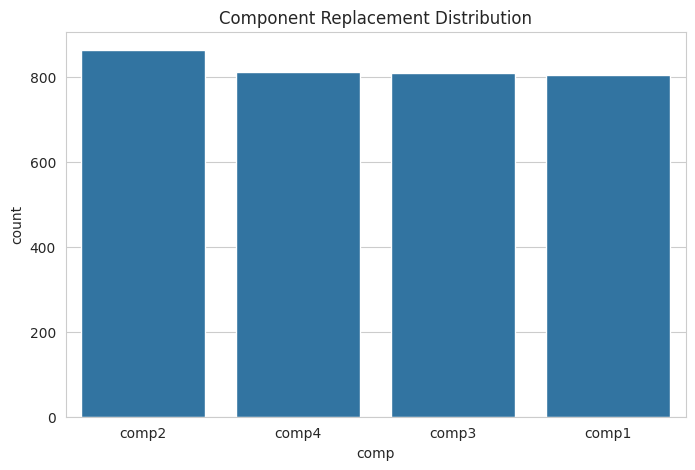

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='comp',
    data=maint
)

plt.title(
    "Component Replacement Distribution"
)

plt.show()

* Replacement counts differ among components.

## 5.3 Component Replacement Percentage

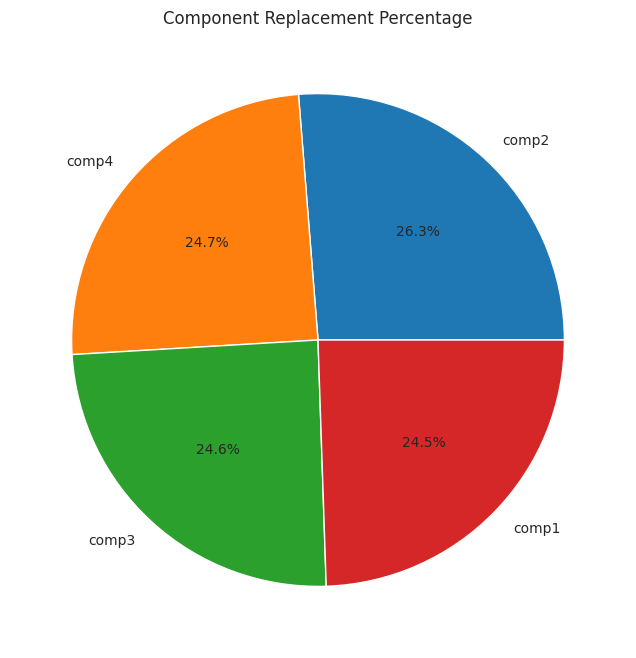

In [10]:
plt.figure(figsize=(8,8))

maint['comp'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title(
    "Component Replacement Percentage"
)

plt.ylabel("")

plt.show()

* Component contribution becomes clearly visible.

# 6 ) Machine-wise Maintenance Analysis

## 6.1 Top Machines with Highest Maintenance

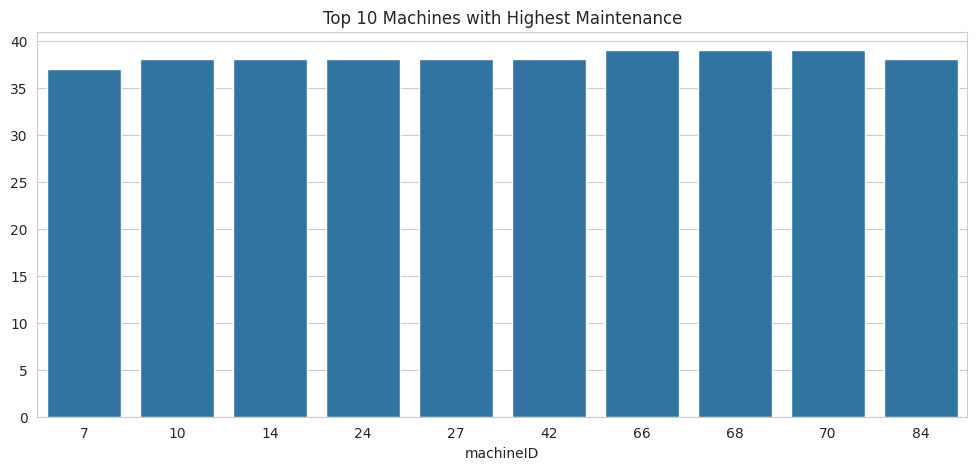

In [11]:
top_maint = (

    maint['machineID']
    .value_counts()
    .head(10)

)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_maint.index,
    y=top_maint.values
)

plt.title(
    "Top 10 Machines with Highest Maintenance"
)

plt.show()

* Some machines require maintenance more frequently.

## 6.2 Maintenance Count per Machine

In [12]:
maint.groupby(
    'machineID'
).size().sort_values(
    ascending=False
).head(20)

,0
machineID,
66,39
70,39
68,39
24,38
42,38
27,38
14,38
84,38
10,38


* Maintenance frequency varies among machines.

# 7 ) Maintenance Timeline Analysis

## 7.1 Datetime Conversion

In [13]:
maint['datetime'] = pd.to_datetime(
    maint['datetime']
)

* Datetime conversion completed successfully.

## 7.2 Daily Maintenance Trend

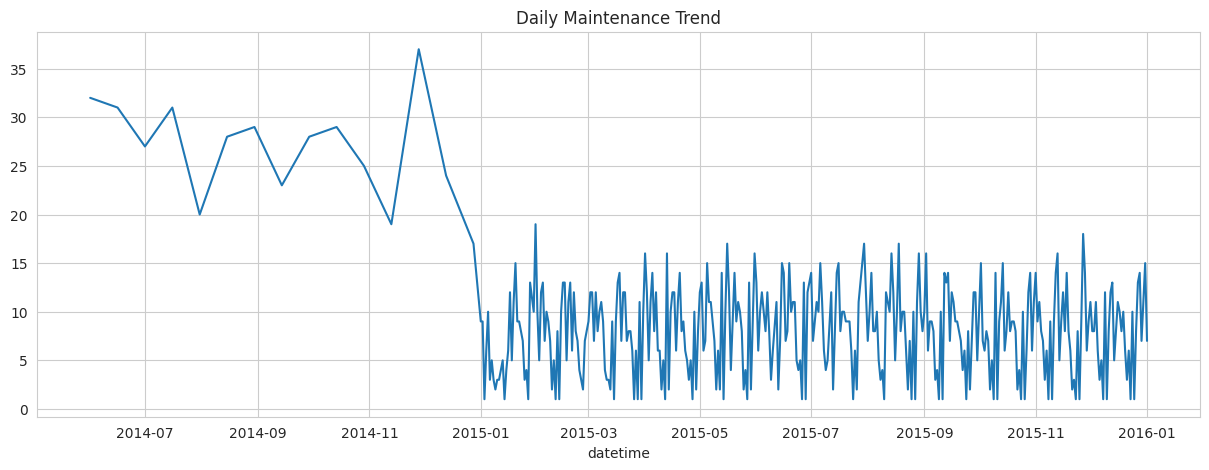

In [14]:
daily_maint = (

    maint.groupby(
        maint['datetime'].dt.date
    )

    .size()

)

plt.figure(figsize=(15,5))

daily_maint.plot()

plt.title(
    "Daily Maintenance Trend"
)

plt.show()

* Maintenance activities vary over time.

## 7.3 Monthly Maintenance Trend

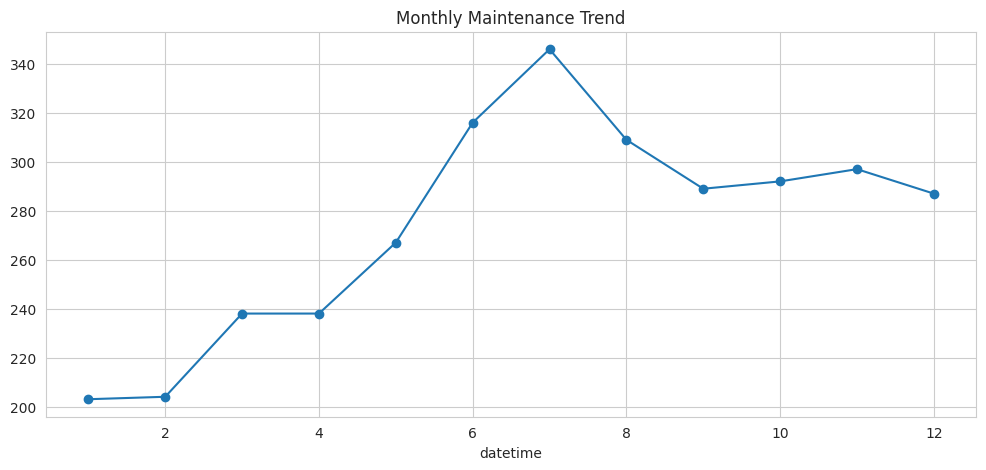

In [15]:
monthly_maint = (

    maint.groupby(
        maint['datetime'].dt.month
    )

    .size()

)

plt.figure(figsize=(12,5))

monthly_maint.plot(
    marker='o'
)

plt.title(
    "Monthly Maintenance Trend"
)

plt.show()

* Monthly maintenance frequency changes over time.

# 8 ) Component-wise Maintenance Analysis

## 8.1 Component Maintenance Frequency

In [16]:
maint['comp'].value_counts()

,count
comp,
comp2,863
comp4,811
comp3,808
comp1,804


* Certain components require more maintenance.

## 8.2 Monthly Component Maintenance Trend

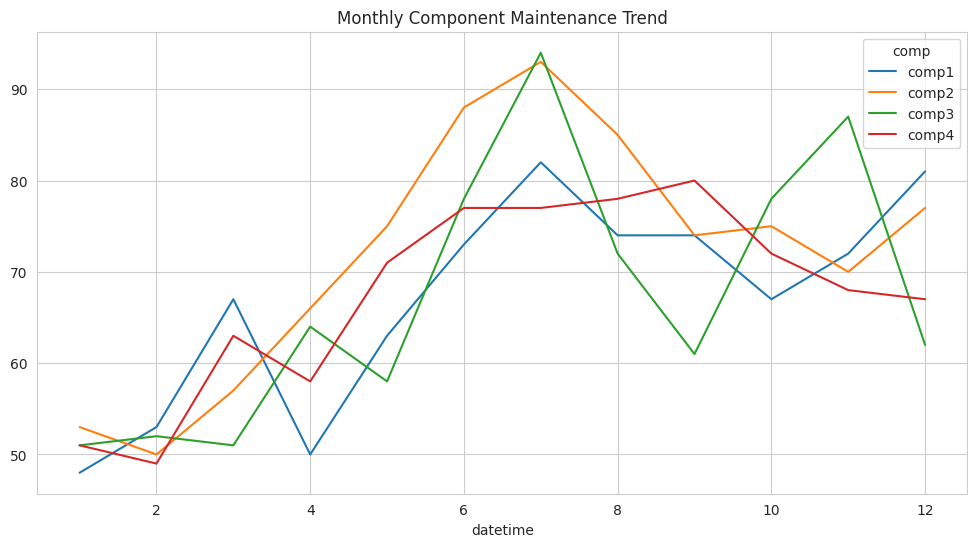

In [17]:
component_month = pd.crosstab(
    maint['datetime'].dt.month,
    maint['comp']
)

component_month.plot(
    figsize=(12,6)
)

plt.title(
    "Monthly Component Maintenance Trend"
)

plt.show()

* Different components exhibit different maintenance patterns.

# 9 ) Maintenance Heatmap Analysis

## 9.1 Machine vs Component Heatmap

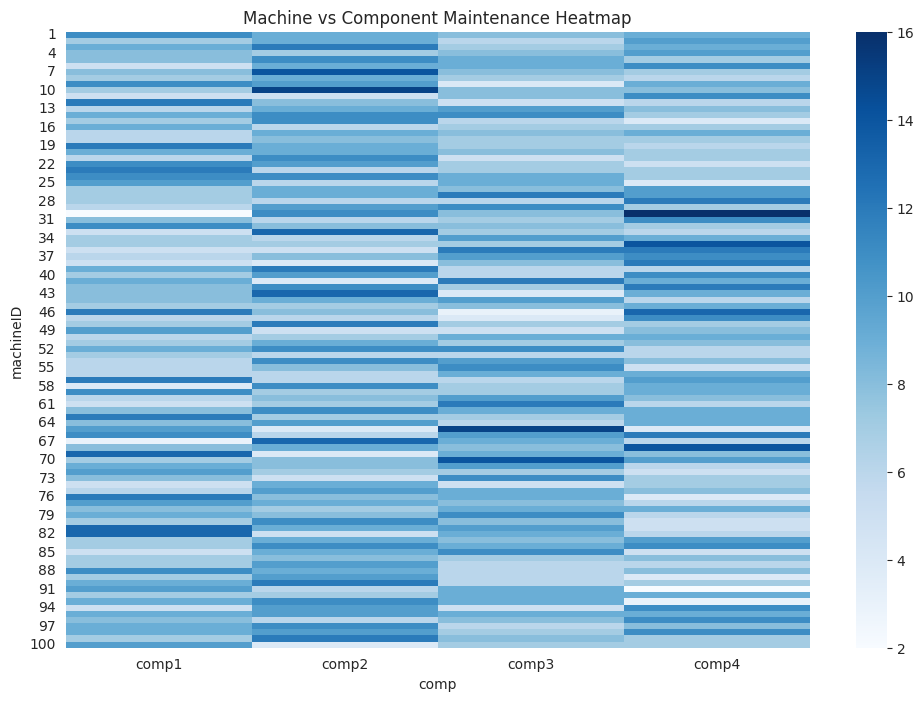

In [18]:
maint_heatmap = pd.crosstab(
    maint['machineID'],
    maint['comp']
)

plt.figure(figsize=(12,8))

sns.heatmap(
    maint_heatmap,
    cmap='Blues'
)

plt.title(
    "Machine vs Component Maintenance Heatmap"
)

plt.show()

* Certain machines require maintenance for specific components more frequently.

# 10 ) Maintenance Risk Analysis

## 10.1 Maintenance Frequency Score

In [19]:
maint_count = (
    maint.groupby('machineID')
    .size()
)

maint_score = (
    maint_count
    /
    maint_count.max()
) * 100

maint_score.sort_values(
    ascending=False
).head(10)

,0
machineID,
66,100.000000
70,100.000000
68,100.000000
24,97.435897
42,97.435897
27,97.435897
14,97.435897
84,97.435897
10,97.435897


* Machines can be ranked based on maintenance frequency.
Business Insight

## 10.2 Top Maintenance Machines

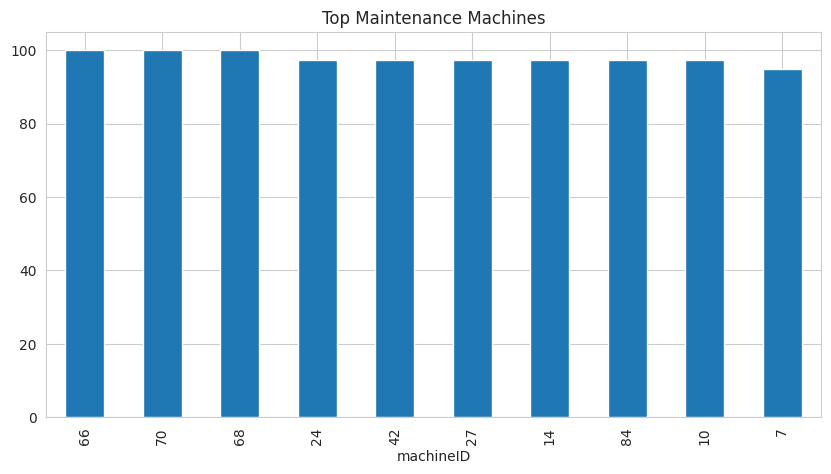

In [20]:
maint_score.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    "Top Maintenance Machines"
)

plt.show()

* Maintenance-intensive machines are clearly identifiable.